<!-- launch-badges -->
<a href="https://colab.research.google.com/github/laban254/ml-for-infrastructure/blob/main/05_sre_applications/model_monitoring/data_drift.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
&nbsp;
<a href="https://mybinder.org/v2/gh/laban254/ml-for-infrastructure/main?urlpath=lab/tree/05_sre_applications/model_monitoring/data_drift.ipynb" target="_blank"><img src="https://mybinder.org/badge_logo.svg" alt="Open in Binder"/></a>

> ▶️ **Run this notebook live** — no install needed. Click a badge above to open it in a free cloud runtime.

# Model Monitoring: Detecting Data Drift

## Objectives
- Understand the concept of **Data Drift** (often called Feature Drift or Covariate Shift), which occurs when the statistical properties of the input data change over time.
- Implement standard statistical tests (e.g., Kolmogorov-Smirnov test) to identify if an infrastructure metric's distribution has fundamentally changed.

## Dataset
- Two synthetic datasets of server request latencies. One represents "historical" data (what the model was trained on), and the other represents "recent" data (production data over the last 24 hours).

## Expected Outcome
- Visual and statistical confirmation that the recent data has drifted from the historical distribution, meaning the ML model's predictions can no longer be trusted until retrained.

## Challenge
- Build a simple Python function that takes two arrays, runs a KS test, and throws a Python `Warning` if drift is detected.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

np.random.seed(42)
sns.set_theme(style="darkgrid")

### 1. Simulating Data Drift
Let's imagine you trained an anomaly detection model on server latencies last month. This month, a new microservice update was pushed, slightly shifting the baseline latency.

In [2]:
# Historical Training Data (Last Month)
# e.g., mean latency is 150ms with a standard deviation of 20
historical_latency = np.random.normal(loc=150, scale=20, size=1000)

# Production Data (Past 24 Hours) - The update slowed things down slightly
# Mean latency is now 165ms
recent_latency = np.random.normal(loc=165, scale=22, size=500)

### 2. Visualizing Drift
The easiest way to detect a problem is visually overlaying the density plots.

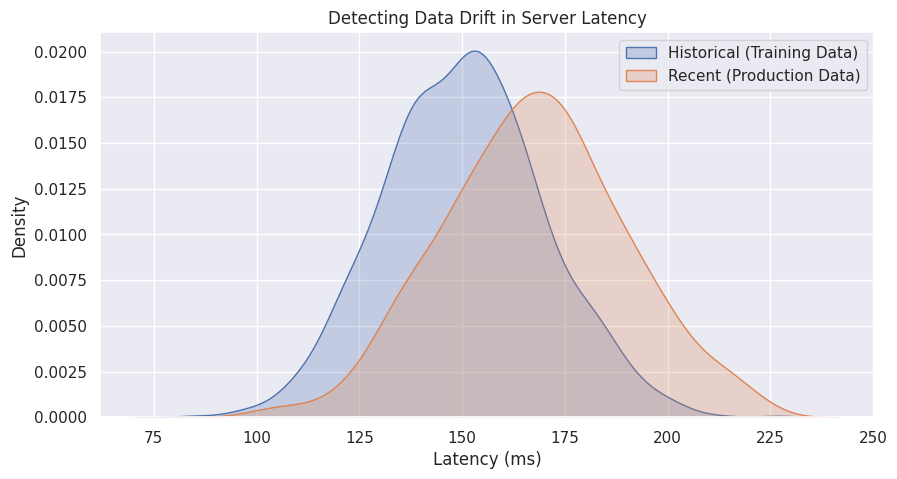

In [3]:
plt.figure(figsize=(10, 5))
sns.kdeplot(historical_latency, fill=True, label='Historical (Training Data)')
sns.kdeplot(recent_latency, fill=True, label='Recent (Production Data)')
plt.title("Detecting Data Drift in Server Latency")
plt.xlabel("Latency (ms)")
plt.ylabel("Density")
plt.legend()
plt.show()

### 3. Statistical Testing: The Kolmogorov-Smirnov Test
Visualizations are great for humans, but for automated monitoring pipelines, we need math. The **Kolmogorov-Smirnov (KS) Test** compares the cumulative distributions of two datasets.
- **Null Hypothesis (H0):** The two samples come from the exact same distribution.
- **p-value:** If $p < 0.05$, we reject the null hypothesis and confirm Drift has occurred.

In [4]:
stat, p_value = ks_2samp(historical_latency, recent_latency)

print(f"KS Statistic: {stat:.4f}")
print(f"p-value: {p_value:.2e}")

if p_value < 0.05:
    print("\n[ALERT] DATA DRIFT DETECTED: Distributions belong to different datasets. Retraining may be required.")
else:
    print("\n[OK] No significant drift detected.")

KS Statistic: 0.3410
p-value: 8.23e-35

[ALERT] DATA DRIFT DETECTED: Distributions belong to different datasets. Retraining may be required.


In [5]:
import warnings

def warn_if_drift(p_value, threshold=0.05):
    """Raise a Python Warning if a KS-test p-value indicates drift (answers the Challenge above)."""
    if p_value < threshold:
        warnings.warn("Drift detected!")

# Demo: reuse the p-value we just computed, which we already know indicates drift
warn_if_drift(p_value)

/tmp/ipykernel_223774/1179437970.py:6: UserWarning: Drift detected!
  warnings.warn("Drift detected!")


---
## 🧪 Try it yourself: how much drift trips the alarm?

Slide the production mean latency away from the historical 150 ms and watch the KS-test p-value. How far does production have to drift before the test calls it?

In [6]:
from ipywidgets import interact, FloatSlider

def check_drift(production_mean=165.0):
    np.random.seed(42)
    recent = np.random.normal(loc=production_mean, scale=22, size=500)
    stat, p = ks_2samp(historical_latency, recent)
    plt.figure(figsize=(10, 4))
    sns.kdeplot(historical_latency, fill=True, label='Historical')
    sns.kdeplot(recent, fill=True, label=f'Production (mean={production_mean:.0f})')
    verdict = 'DRIFT DETECTED' if p < 0.05 else 'no drift'
    plt.title(f'KS p-value = {p:.2e}  ->  {verdict}')
    plt.xlabel('Latency (ms)'); plt.legend(); plt.show()

interact(check_drift, production_mean=FloatSlider(
    min=150, max=220, step=5, value=165));

interactive(children=(FloatSlider(value=165.0, description='production_mean', max=220.0, min=150.0, step=5.0),…

## 📝 Exercise: drift on a second feature

Latency is rarely the only thing that shifts. Simulate a **memory-usage** feature (historical mean 60%, production mean 75%) and run the same KS test. Does it drift too?

```python
# your code here
```

<details><summary>💡 Reveal solution</summary>

```python
hist_mem = np.random.normal(60, 8, 1000)
prod_mem = np.random.normal(75, 9, 500)
stat, p = ks_2samp(hist_mem, prod_mem)
print(f'Memory KS p-value: {p:.2e} -> ' + ('DRIFT' if p < 0.05 else 'OK'))
```
</details>